In [2]:
import os

from tqdm.notebook import tqdm

import numpy as np
from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.special import erf
# from scipy.stats import norm

import kemstem

In [3]:
def calculate_R(raw_data, regressed):
    sse = np.sum(np.square(raw_data - regressed))
    sst = np.sum(np.square(raw_data - raw_data.mean()))
    return 1 - sse/sst

def fit(f, xdata, ydata, plot=False, **kwargs):
    xdata = np.array(xdata).flatten()
    ydata = np.array(ydata).flatten()
    if plot:
        plt.plot(xdata, ydata, 'k.')
        if 'sigma' in kwargs:
            plt.errorbar(xdata, ydata, kwargs['sigma'], fmt='none', c='k')
    popt, pcov = curve_fit(f, xdata, ydata, **kwargs)
    perr = np.sqrt(np.diag(pcov))
    R = calculate_R(ydata, f(xdata, *popt))
    if plot:
        xlim, ylim = plt.xlim(), plt.ylim()
        plt.xlim(*xlim)
        plt.ylim(*ylim)
        x = np.linspace(*xlim, 100)
        plt.plot(x, f(x, *popt), 'r--')
        plt.show()
    return popt, perr, R

In [5]:
results = {
    '2V': loadmat('./Si2V1-Niter1000.mat'),
    '5V': loadmat('./Si5V2-Niter1000.mat'),
    '8V': loadmat('./Si8V2-Niter1000.mat'),
}

In [ ]:
DZ = {}
recons = {}

for key in results.keys():
    result = results[key]
    roi = result['p']['object_ROI'][0][0][0]
    roix = roi[0].T
    roiy = roi[1]

    DZ.update({key: result['outputs']['z_distance'].item().item()})
    recons.update({key: result['object'][roix, roiy]})

In [ ]:
column_positions = {}

for key in results.keys():
    recon = recons[key]
    image = np.angle(recon[:,:,recon.shape[-1] // 2])
    blurred_image = gaussian_filter(image, 1)
    distance = 2
    threshold = 0.5
    c0 = kemstem.find_columns(blurred_image, distance=distance, threshold=threshold)

    column_positions.update({key: c0})

In [15]:
WINDOW = 1

column_lists = {}

for key in results.keys():

    c0 = column_positions[key]
    recon = recons[key]

    column_list = []
    for i, (cx, cy) in enumerate(tqdm(c0)):
        wx_start, wx_end = cx-WINDOW, cx+WINDOW+1
        wy_start, wy_end = cy-WINDOW, cy+WINDOW+1
        column = np.angle(recon)[wx_start:wx_end, wy_start:wy_end, 1:].mean(axis=(0, 1))
        column_list.append(column)

    column_lists.update({key: column_list})

  0%|          | 0/1464 [00:00<?, ?it/s]

  0%|          | 0/1004 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

In [ ]:
def double_erf(x, p0, p1, q, x0, x1):
    return p0 + p1 * (erf(q*(x - x0)) - erf(q*(x - x1)))

In [ ]:
crystalline_heights = {}
safe_height_indices = {}

for key in results.keys():

    columns = column_lists[key]
    dz = DZ[key]

    crystalline = []

    for column in tqdm(columns):
        popt, _, _ = fit(
            double_erf, np.arange(len(column)), column, plot=False,
            p0=[-0.03846732,  0.28181914,  0.30406586,  3.74047066, 12.6762897 ],
            # bounds=bounds,
            maxfev=10000
            )
        p0, p1, q, x0, x1 = popt

        crystalline.append((x1 - x0) * dz)

    crystalline_heights.update({key: np.array(crystalline)})

  0%|          | 0/1464 [00:00<?, ?it/s]

  0%|          | 0/1004 [00:00<?, ?it/s]

  0%|          | 0/937 [00:00<?, ?it/s]

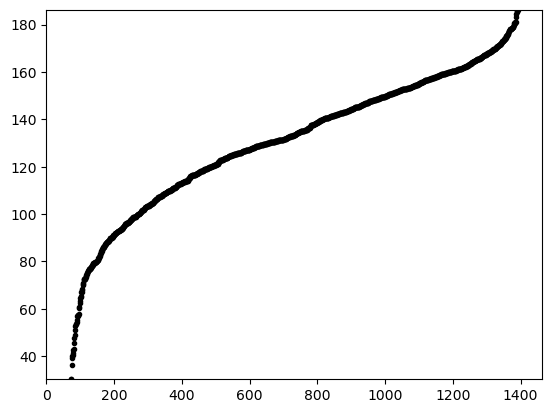

245.0 55.8145049307754


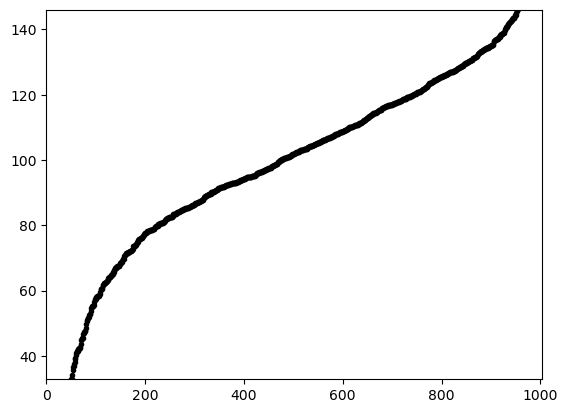

281.0 89.54863642387284


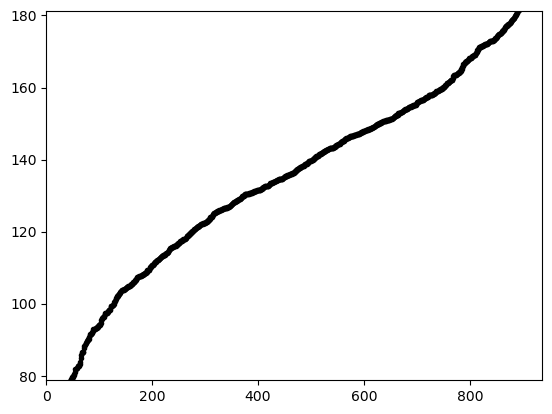

336.0 99.64506469888937


In [144]:
for key in results.keys():
    crystalline = crystalline_heights[key]
    sorted_heights = np.sort(crystalline)

    ymin = sorted_heights[1 * len(sorted_heights) // 20]
    ymax = sorted_heights[19 * len(sorted_heights) // 20]

    plt.plot(sorted_heights, 'k.')
    xlim = plt.xlim(0, len(crystalline))
    ylim = plt.ylim(ymin, ymax)
    plt.show()
    safe_height_index = np.where(
        (crystalline > ymin) & (crystalline < ymax)
        )
    safe_height_indices.update({key: safe_height_index})

    total_thickness = recons[key].shape[-1] * DZ[key]

    print(total_thickness, (total_thickness - np.median(crystalline)) / 2)

In [145]:
for key, recon in recons.items():
    print(key)
    print(recon.shape[:-1])
    print([(recon.shape[0] * i) // 8 for i in [1, 3, 5, 7]])

2V
(573, 573)
[71, 214, 358, 501]
5V
(580, 580)
[72, 217, 362, 507]
8V
(581, 581)
[72, 217, 363, 508]


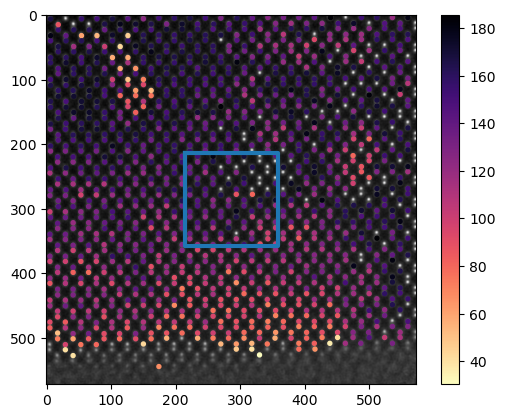

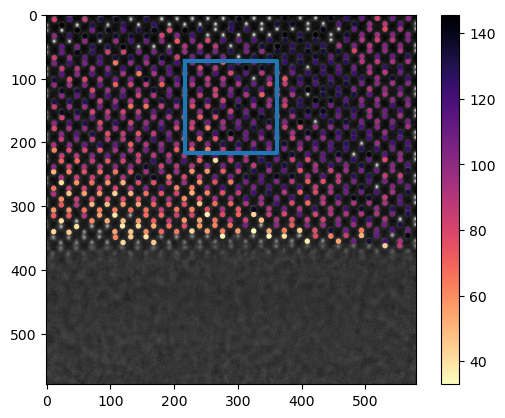

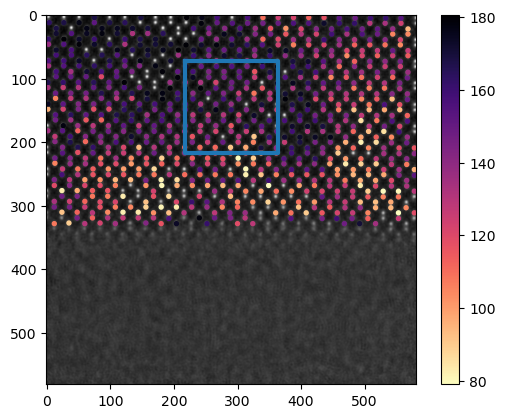

In [146]:
thickness_rois = {
    '2V': [[214, 358], [214, 358]],
    '5V': [[217, 362], [ 72, 217]],
    '8V': [[217, 363], [ 72, 217]]
}
for key in results.keys():

    recon = recons[key]
    heights = crystalline_heights[key]
    c0 = column_positions[key]
    idx = safe_height_indices[key]
    dz = DZ[key]

    plt.imshow(np.angle(recon).sum(axis=-1), cmap='gray')
    # plt.axis('off')
    plt.scatter(
        c0[:, 1][idx], c0[:, 0][idx], c=np.array(heights[idx]), s=8, cmap='magma_r',
        )
    cbar = plt.colorbar()

    (x0, x1), (y0, y1) = thickness_rois[key]
    plt.plot([x0, x0, x1, x1, x0], [y0, y1, y1, y0, y0], lw=3)

    plt.show()


In [147]:
roi_indices = {}

for key in results.keys():
    c0 = column_positions[key]
    indices = []
    (x0, x1), (y0, y1) = thickness_rois[key]
    idx = np.where(
        (c0[:,0] >= y0) & (c0[:,0] <= y1) & (c0[:,1] >= x0) & (c0[:,1] <= x1) 
    )
    indices.append(idx)
    roi_indices.update({key: indices})

In [148]:
roi_crystalline_height_means = {}
roi_crystalline_height_stds = {}
roi_amorphous_height_means = {}
roi_amorphous_height_stds = {}

for key in results.keys():

    safe_idx = safe_height_indices[key]
    roi_idx = roi_indices[key]
    total_thickness = recons[key].shape[-1] * DZ[key]

    idx = np.intersect1d(safe_idx, roi_idx)

    height = crystalline_heights[key]

    crystalline_mean = height[idx].mean()
    crystalline_std = height[idx].std()
    amorphous_mean = (total_thickness - crystalline_mean) / 2
    amorphous_std = crystalline_std / 2

    roi_crystalline_height_means.update({key: crystalline_mean})
    roi_crystalline_height_stds.update({key: crystalline_std})
    roi_amorphous_height_means.update({key: amorphous_mean})
    roi_amorphous_height_stds.update({key: amorphous_std})

In [158]:
roi_indices['2V'][0][0]

array([   4,   16,   61,   72,   75,   77,   84,   92,  103,  119,  123,
        142,  157,  173,  174,  185,  202,  209,  240,  245,  253,  259,
        273,  302,  314,  323,  325,  328,  330,  333,  359,  369,  385,
        391,  396,  418,  448,  487,  494,  515,  518,  528,  539,  554,
        556,  560,  594,  601,  602,  607,  616,  631,  657,  668,  693,
        706,  722,  741,  747,  782,  787,  793,  801,  814,  831,  841,
        854,  861,  865,  873,  877,  896,  910,  921,  926,  929,  942,
        945,  952,  977,  981,  990, 1006, 1010, 1011, 1013, 1019, 1060,
       1076, 1081, 1096, 1102, 1121, 1135, 1177, 1185, 1212, 1224, 1235,
       1244, 1275, 1291])

2V
Crystalline thickness: 136.780 ± 21.382
Amorphous thickness:    54.110 ±  10.691
(# of counted columns = 85/102)


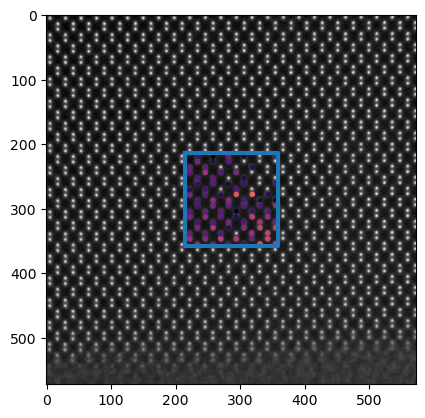

5V
Crystalline thickness: 103.381 ± 18.827
Amorphous thickness:    88.810 ±  9.414
(# of counted columns = 105/106)


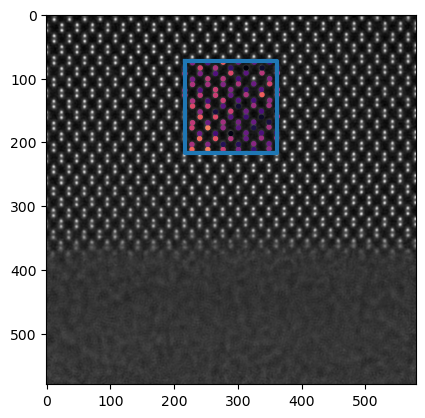

8V
Crystalline thickness: 141.043 ± 19.590
Amorphous thickness:    97.479 ±  9.795
(# of counted columns = 110/118)


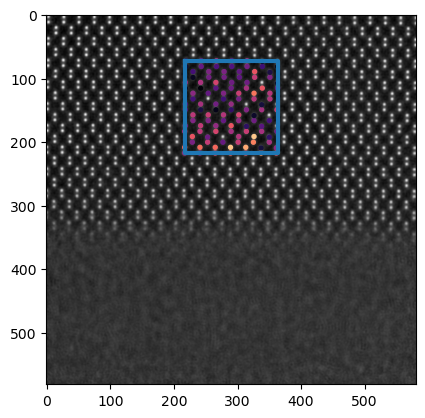

In [161]:
for key in results.keys():

    recon = recons[key]
    heights = crystalline_heights[key]
    c0 = column_positions[key]

    crystalline_mean = roi_crystalline_height_means[key]
    crystalline_std = roi_crystalline_height_stds[key]
    amorphous_mean = roi_amorphous_height_means[key]
    amorphous_std = roi_amorphous_height_stds[key]


    safe_idx = safe_height_indices[key]
    roi_idx = roi_indices[key]
    idx = np.intersect1d(safe_idx, roi_idx)

    print(key)
    print(f"Crystalline thickness: {crystalline_mean:.3f} ± {crystalline_std:.3f}")
    print(f"Amorphous thickness:    {amorphous_mean:.3f} ±  {amorphous_std:.3f}")
    print(f"(# of counted columns = {len(idx)}/{len(roi_idx[0][0])})")

    (x0, x1), (y0, y1) = thickness_rois[key]
    plt.imshow(np.angle(recon).sum(axis=-1), cmap='gray')
    plt.plot([x0, x0, x1, x1, x0], [y0, y1, y1, y0, y0], lw=3)

    # plt.axis('off')
    plt.scatter(
        c0[:, 1][idx], c0[:, 0][idx], c=np.array(heights)[idx], s=8, cmap='magma_r',
        vmin=heights[safe_idx].min(),
        vmax=heights[safe_idx].max()
        )
    # cbar = plt.colorbar()
    plt.show()


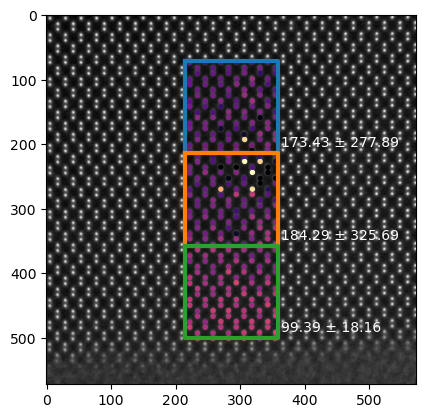

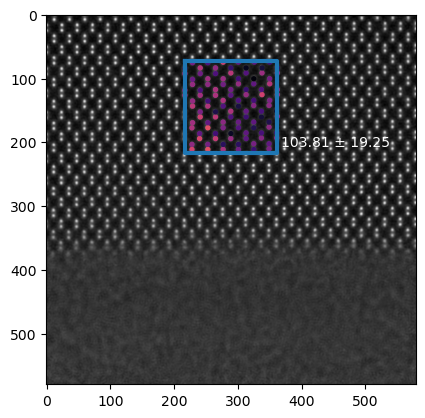

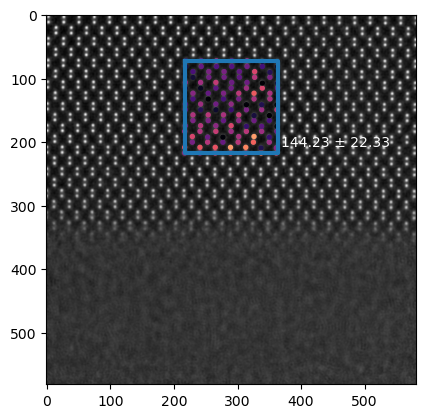

In [ ]:
for key in results.keys():

    recon = recons[key]
    heights = crystalline_heights[key]
    c0 = column_positions[key]

    top = tops[key]
    middle = middles[key]
    bottom = bottoms[key]
    top_std = top_stds[key]
    middle_std = middle_stds[key]
    bottom_std = bottom_stds[key]

    plt.imshow(np.angle(recon).sum(axis=-1), cmap='gray')

    for i, roi in enumerate(thickness_rois[key]):

        idx = roi_indices[key][i]

        (x0, x1), (y0, y1) = roi
        plt.plot([x0, x0, x1, x1, x0], [y0, y1, y1, y0, y0], lw=3)
        plt.text(x1+5, y1-10, f"{middle[i]:.2f} ± {middle_std[i]:.2f}", color='white')

        sorted_heights = np.sort(heights)

        # plt.axis('off')
        plt.scatter(
            c0[:, 1][idx], c0[:, 0][idx], c=np.array(heights)[idx], s=8, cmap='magma_r',
            vmax=sorted_heights[-30], 
            vmin=sorted_heights[30]
            )
        # cbar = plt.colorbar()


    plt.show()
